Status: exploratory

# Supplemental figure: all connected components, all samples

Companion to `analyze_visium_hd.ipynb`'s row 3 (spatial map colored by
exponential-saturation correction, piecewise-linear elbow as an unfilled
outline). Instead of one auto-selected component per dataset type, this
shows **every** spatially-connected component (>100 bins) of **every**
sample, overlaid on its own panel
(`visium_hd.plot_correction_map_multi`) — e.g. a TMA's ~44 cores all show up
together on one panel, each colored/outlined from its own independent fit.
One panel per sample (12 total), columns = dataset type to match the main
figure's column semantics.

In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str((Path("..") / ".." / "src" / "utils").resolve()))
import visium_hd

plt.rcParams['svg.fonttype'] = 'none'

/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Paths & datasets

Same `src/figure4/sample_manifest.csv` as the main notebook — single source
of truth for the 12 samples (4 visium demo, 4 visium custom, 4 STOmics
custom).

In [2]:
with open("../../fit_palette.json") as f:
    pal = json.load(f)
BSPBLUE = pal["Piecewise Linear Fit"]
EXPSAT_COLOR = pal["Exponential Saturation Fit"]

MANIFEST_PATH = "../../src/figure4/sample_manifest.csv"
SAVE_SVG = "../../result_plots/figure4/figure4_supplement_all_components.svg"
SAVE_PDF = "../../result_plots/figure4/figure4_supplement_all_components.pdf"

LOADERS = {"visium": visium_hd.analyze_dataset, "stomics": visium_hd.analyze_stomics_dataset}

ALL_SAMPLES = pd.read_csv(MANIFEST_PATH)
ALL_SAMPLES

,name,dataset_type,loader,h5ad_path,bin_size_um,tissue_mask_path
0,breast_cancer,visium_demo,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium/...,8.0,NaN
1,pancreas,visium_demo,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium/...,8.0,NaN
2,colon_cancer_ff,visium_demo,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium/...,8.0,NaN
3,breast_cancer_tma,visium_demo,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium/...,8.0,NaN
4,Pat1,visium_custom,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium_...,8.0,NaN
5,Pat2,visium_custom,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium_...,8.0,NaN
6,Pat3,visium_custom,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium_...,8.0,NaN
7,Pat4,visium_custom,visium,/home/woody/iwbn/iwbn007h/spatial_data/visium_...,8.0,NaN
8,A02991D1,stomics_custom,stomics,/home/woody/iwbn/iwbn007h/spatial_data/stomics...,10.0,/home/woody/iwbn/iwbn007h/spatial_data/stomics...
9,A02994C6,stomics_custom,stomics,/home/woody/iwbn/iwbn007h/spatial_data/stomics...,10.0,/home/woody/iwbn/iwbn007h/spatial_data/stomics...


## Compute

Loads every sample via its loader (`visium_hd.analyze_dataset` /
`analyze_stomics_dataset`), which does its own connected-component
splitting and per-component piecewise-linear + exponential-saturation
fitting (see `visium_hd._border_fit_from_adata`'s docstring for why
distances are computed per component rather than pooled). No BLADE here —
not needed for this plot. This re-loads/re-fits from the h5ad files rather
than reading `results/figure4/per_sample/*.json`, since those only hold
scalar summaries, not the spatial arrays and fit objects this plot needs.

In [3]:
all_components = {}
for _, sample in ALL_SAMPLES.iterrows():
    name = sample["name"]
    loader = LOADERS[sample["loader"]]
    print(f"loading {name} ({sample['dataset_type']})...", flush=True)
    try:
        components = loader(sample["h5ad_path"])
        all_components[name] = components
        print(f"  {len(components)} component(s)")
    except Exception as e:
        print(f"  FAILED: {e}")
        all_components[name] = None

loading breast_cancer (visium_demo)...


INFO     Creating graph using `None` transform and `1` libraries.                                                  


  13 component(s)
loading pancreas (visium_demo)...


INFO     Creating graph using `None` transform and `1` libraries.                                                  


  8 component(s)
loading colon_cancer_ff (visium_demo)...


...

  7 component(s)
loading Y01087DD (stomics_custom)...


INFO     Creating graph using `None` transform and `1` libraries.                                                  


  6 component(s)
loading Y01084J8 (stomics_custom)...


INFO     Creating graph using `None` transform and `1` libraries.                                                  


  9 component(s)


## Combined figure (one panel per sample)

Columns = dataset type (matching the main figure's column semantics), rows
= the 4 samples of that type. Each panel overlays all of that sample's
components: exp-sat correction color-coded in shades of `EXPSAT_COLOR`
(shared color scale within a panel, since all of a sample's components are
compared together), each component's own piecewise-linear elbow drawn as an
unfilled outline in `BSPBLUE`.

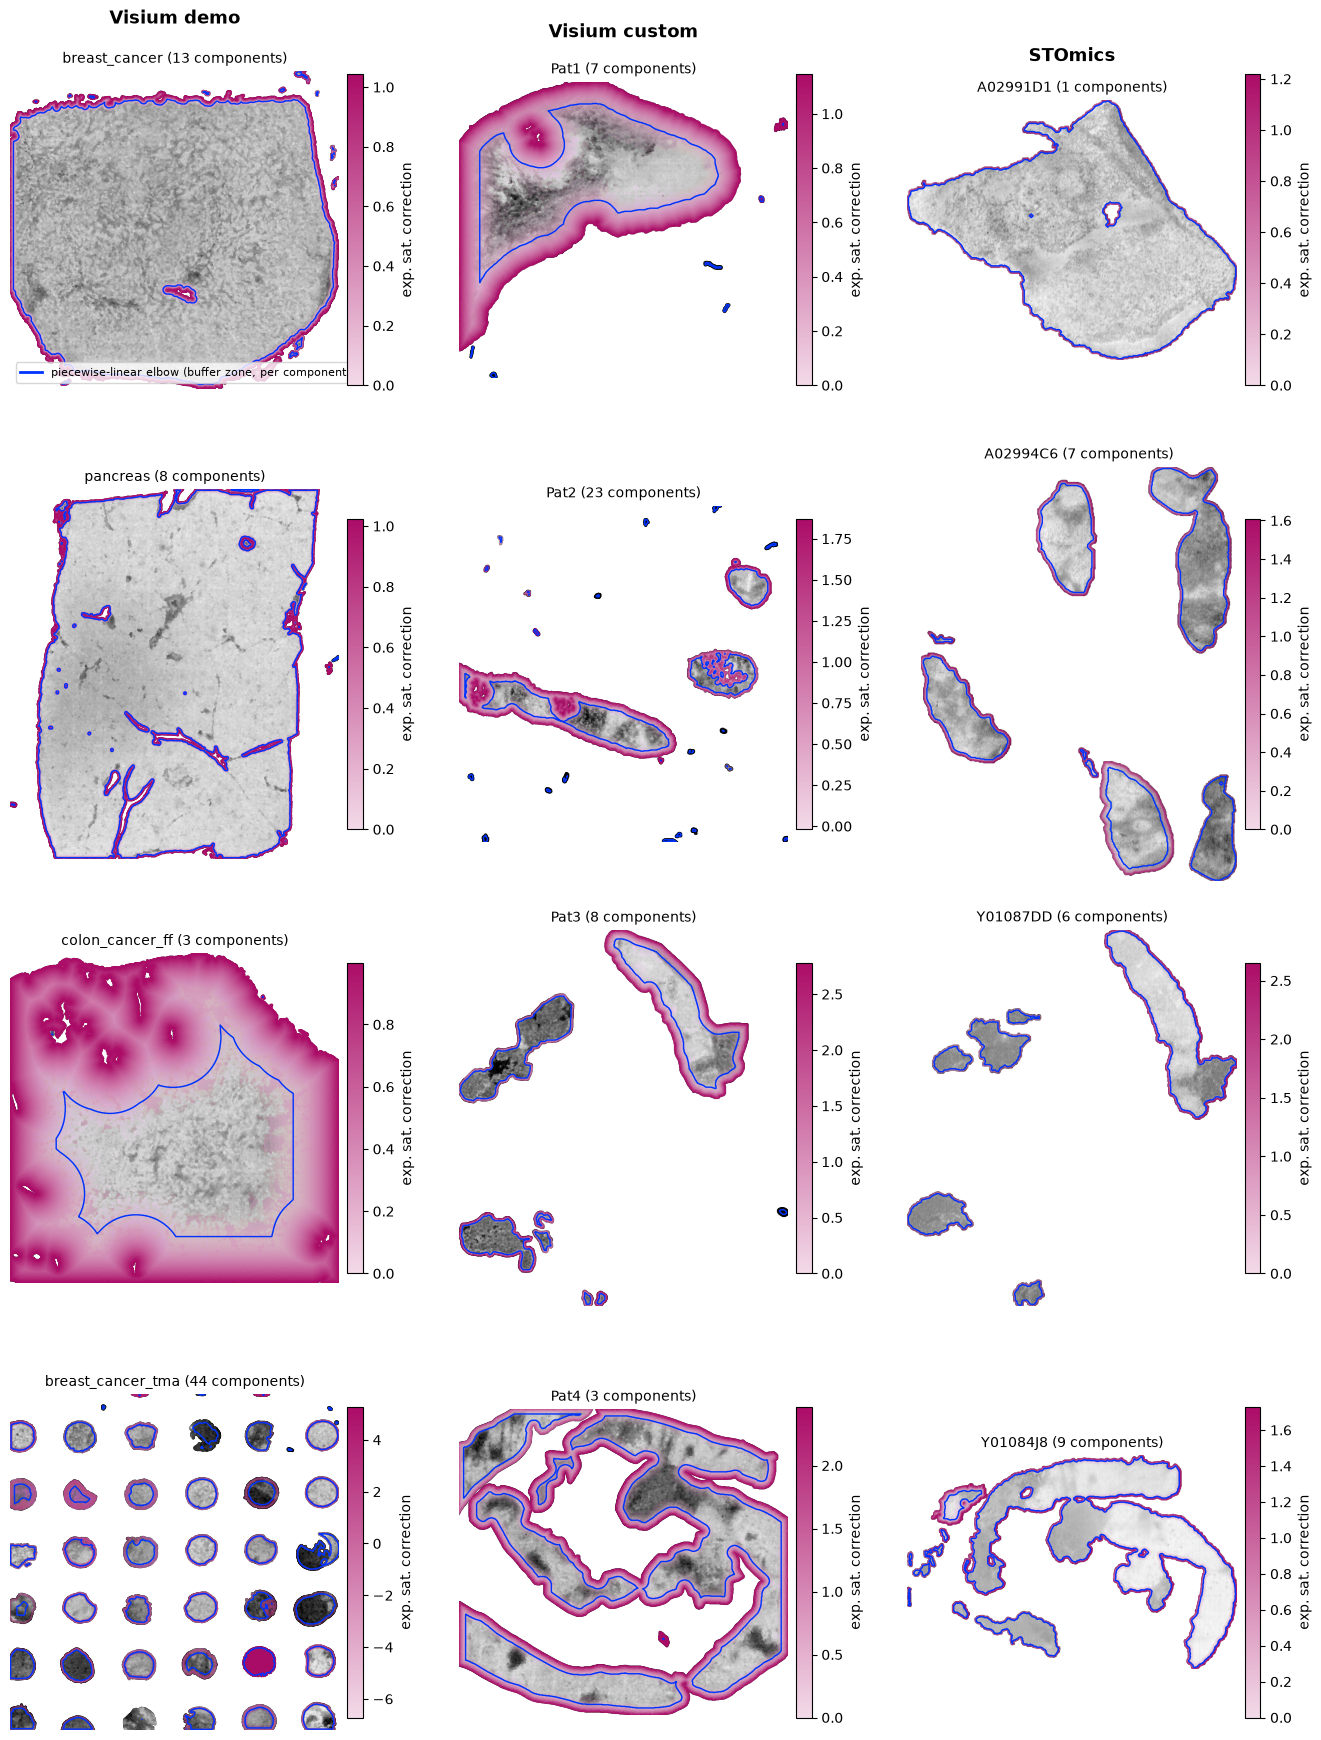

In [4]:
GRID_ORDER = ["visium_demo", "visium_custom", "stomics_custom"]
COLUMN_TITLES = {"visium_demo": "Visium demo", "visium_custom": "Visium custom", "stomics_custom": "STOmics"}
samples_by_type = {t: ALL_SAMPLES.loc[ALL_SAMPLES["dataset_type"] == t, "name"].tolist() for t in GRID_ORDER}
n_rows = max(len(v) for v in samples_by_type.values())
n_cols = len(GRID_ORDER)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.5, n_rows * 4.5))

for col, dtype in enumerate(GRID_ORDER):
    names = samples_by_type[dtype]
    for row in range(n_rows):
        ax = axes[row, col]
        if row >= len(names):
            ax.axis("off")
            continue
        name = names[row]
        components = all_components.get(name)
        if not components:
            ax.text(0.5, 0.5, f"{name}\n(failed to load)", ha="center", va="center", transform=ax.transAxes)
            ax.axis("off")
            continue
        visium_hd.plot_correction_map_multi(
            ax, components, exp_color=EXPSAT_COLOR, boundary_color=BSPBLUE,
            title=f"{name} ({len(components)} components)",
            add_legend=(row == 0 and col == 0),
        )
    axes[0, col].annotate(COLUMN_TITLES[dtype], xy=(0.5, 1.15), xycoords="axes fraction",
                           ha="center", fontsize=13, fontweight="bold")

fig.tight_layout()
os.makedirs(os.path.dirname(SAVE_SVG), exist_ok=True)
fig.savefig(SAVE_SVG, bbox_inches="tight")
#fig.savefig(SAVE_PDF, bbox_inches="tight")
plt.show()

## Second approach: image-derived tissue vs. counts-derived tissue

Everything above defines "tissue" purely from the counts matrix (a bin is
tissue if it's present in the filtered/analysis matrix at all; the border
is where grid-neighbors run out). This section adds a completely
independent, image-only tissue call:

- **Visium** (demo + custom): the sample's own embedded hires H&E/CytAssist
  image is segmented directly (`visium_hd.segment_tissue_from_rgb` --
  grayscale, heavy Gaussian blur, Otsu threshold, then morphological
  clean-up into solid blobs). One fixed parameter set for all 8 samples,
  confirmed visually on both a single bulk tissue piece and ~100 small TMA
  cores.
- **STOmics**: these h5ad files carry no embedded image at all (bare
  `outs/analysis/*.h5ad` exports). BGI's own precomputed bulk tissue-region
  mask (`*_ssDNA_tissue_cut.tif`, copied into `spatial_data/stomics/`
  alongside each h5ad -- see that folder's README) is used instead;
  confirmed to align with each sample's bins in the same raw pixel
  coordinate space (97-99% of bins land on a `tissue_cut==1` pixel).

Overlaying the two lets you see, per sample, where the RNA-detected
footprint (red) diverges from the physical tissue outline the image itself
shows (blue) -- bins reading as counts-positive tissue outside the blue
region are a direct, image-grounded signal of the same diffusion/border
effect the rest of this notebook quantifies via distance-to-border curve
fitting, from a completely different angle. Purely visual for now -- no
distance/overlap statistic is computed here.

### Compute image-derived masks

One `visium_hd.get_sample_tissue_mask(row)` call per sample (dispatches on
the manifest's `loader` column). Reuses `all_components` from the cell
above -- no second load of any h5ad.

In [5]:
tissue_masks = {}
for _, sample in ALL_SAMPLES.iterrows():
    name = sample["name"]
    print(f"segmenting {name} ({sample['dataset_type']})...", flush=True)
    try:
        tissue_masks[name] = visium_hd.get_sample_tissue_mask(sample)
    except Exception as e:
        print(f"  FAILED: {e}")
        tissue_masks[name] = None

segmenting breast_cancer (visium_demo)...


/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/src/utils/visium_hd.py:296: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  mask = binary_closing(mask, disk(close_radius))


/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/src/utils/visium_hd.py:297: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_holes(mask, area_threshold=min_hole_area)


/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/src/utils/visium_hd.py:298: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size=min_object_area)


segmenting pancreas (visium_demo)...


...

/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/src/utils/visium_hd.py:298: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = remove_small_objects(mask, min_size=min_object_area)


segmenting A02991D1 (stomics_custom)...


segmenting A02994C6 (stomics_custom)...


segmenting Y01087DD (stomics_custom)...


segmenting Y01084J8 (stomics_custom)...


### Combined figure (one panel per sample)

Same layout as the figure above (columns = dataset type, rows = the 4
samples of that type). Blue = image-derived tissue mask, red = every
analyzed bin (all components, pooled) -- overlap reads as a muted
red/blue blend, mismatch in either direction shows as a solid, unmixed
color.

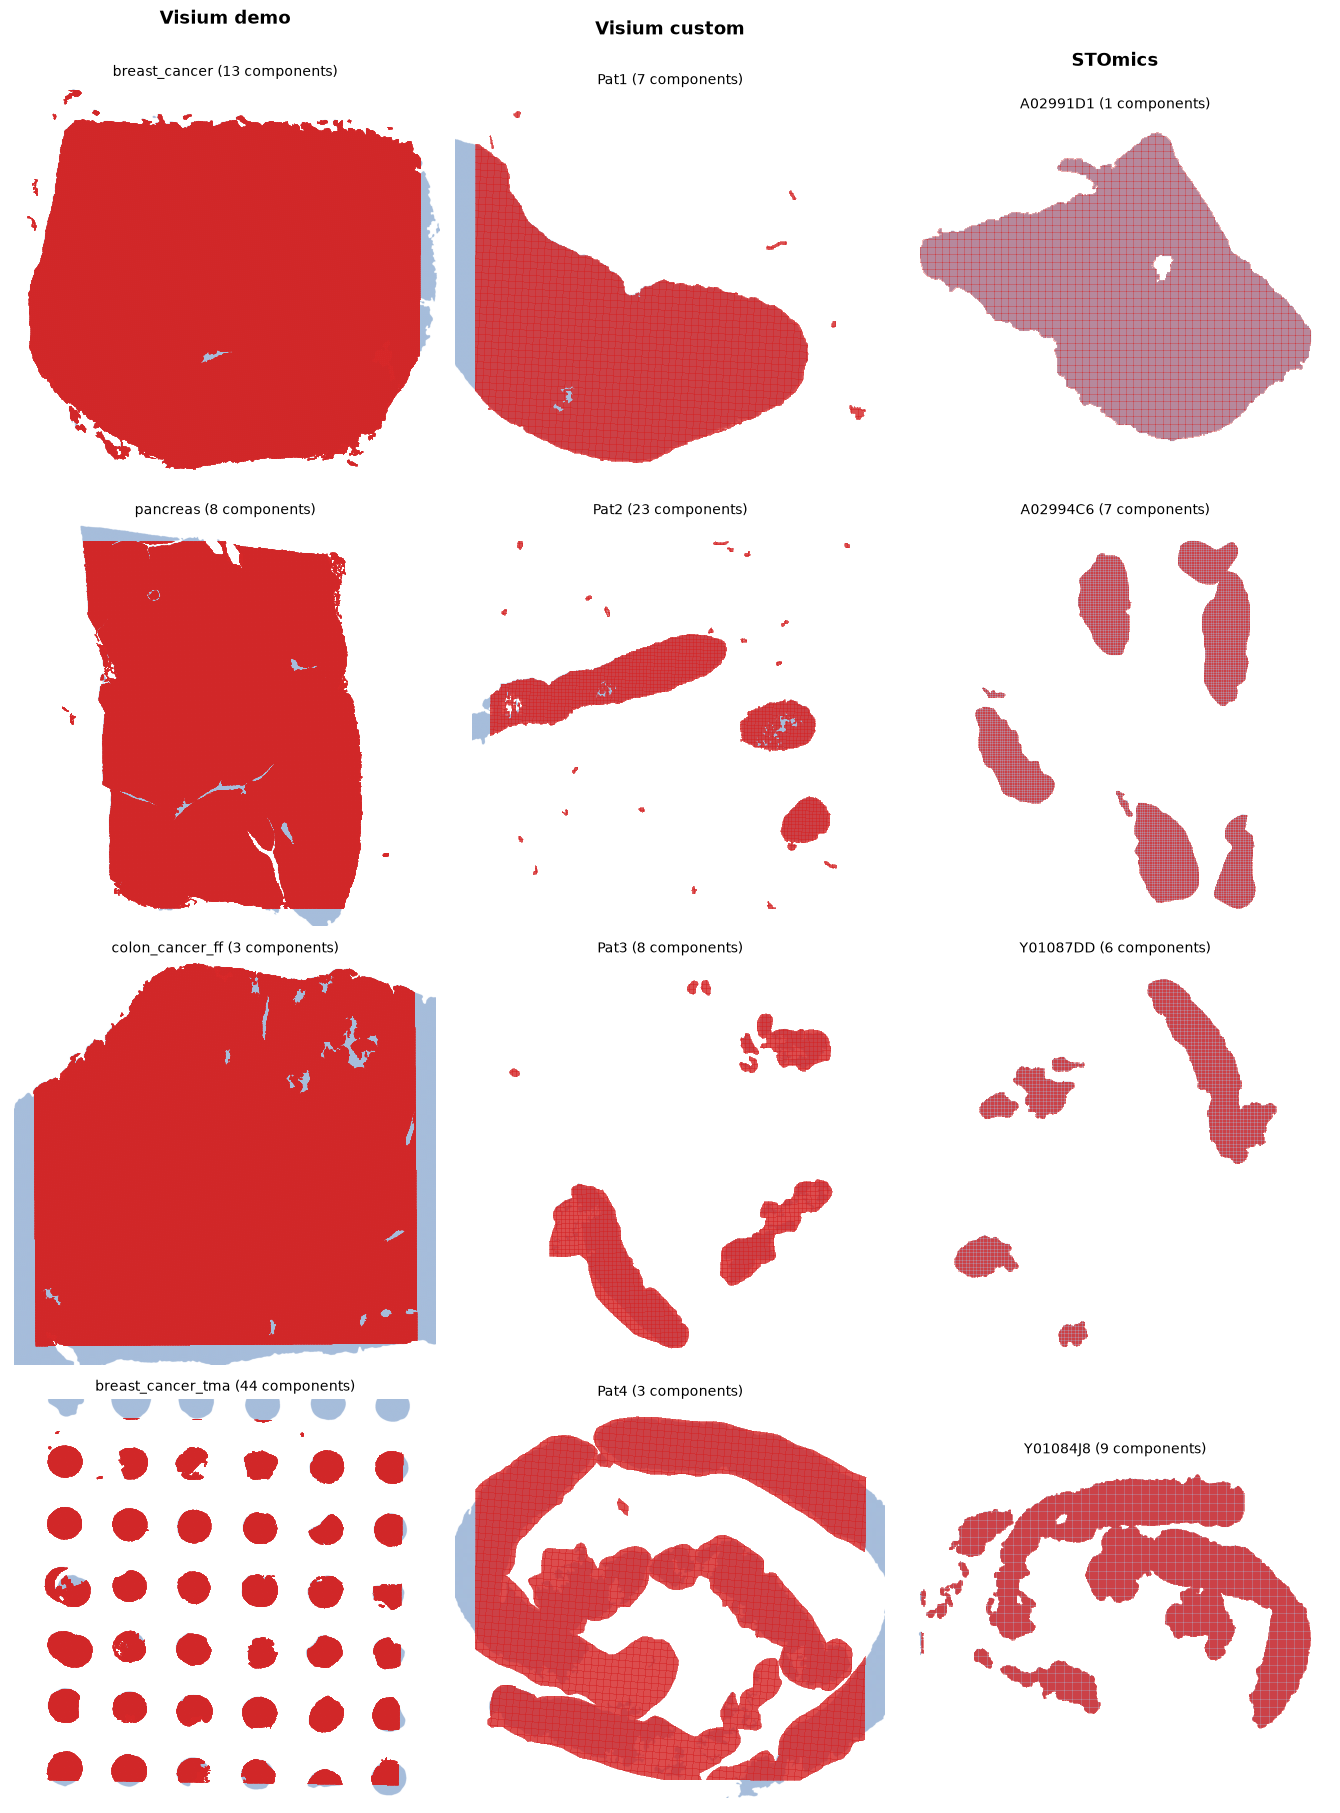

In [6]:
SAVE_SEG_SVG = "../../result_plots/figure4/figure4_supplement_image_segmentation.svg"

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4.5, n_rows * 4.5))

for col, dtype in enumerate(GRID_ORDER):
    names = samples_by_type[dtype]
    for row in range(n_rows):
        ax = axes[row, col]
        if row >= len(names):
            ax.axis("off")
            continue
        name = names[row]
        components = all_components.get(name)
        mask_and_scale = tissue_masks.get(name)
        if not components or mask_and_scale is None:
            ax.text(0.5, 0.5, f"{name}\n(failed to load)", ha="center", va="center", transform=ax.transAxes)
            ax.axis("off")
            continue
        mask, pixel_scale = mask_and_scale
        visium_hd.plot_image_tissue_vs_counts(
            ax, components, mask, pixel_scale, title=f"{name} ({len(components)} components)",
        )
    axes[0, col].annotate(COLUMN_TITLES[dtype], xy=(0.5, 1.15), xycoords="axes fraction",
                           ha="center", fontsize=13, fontweight="bold")

fig.tight_layout()
os.makedirs(os.path.dirname(SAVE_SEG_SVG), exist_ok=True)
fig.savefig(SAVE_SEG_SVG, bbox_inches="tight")
plt.show()